<div style="background: linear-gradient(135deg, #0f172a, #1e293b); color:white; padding:25px; border-radius:10px;
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;">Market Sentiment Analysis from Tweets</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#94a3b8;">
    Transformer Encoder Fine-Tuning
  </h3>

  <hr style="width:60%; border:1px solid #475569; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Text Mining (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#cbd5e1;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e2e8f0; padding:18px; border-radius:6px;">
This notebook fine-tunes two pretrained Transformer Encoders end-to-end on the Bearish/Bullish/Neutral classification task. Unlike notebook 06, here the encoder weights are <b>updated</b> by the training loss, not held frozen.

This satisfies criterion 4.5 of the handout: <b>fine-tuned Transformer Encoders</b> as classification models. RNN/LSTM in notebooks 04-05 count as advanced traditional ML and do not satisfy this criterion.

The two encoders are the strongest from notebook 06:
<ul>
  <li><b>Twitter-RoBERTa</b> (<code>cardiffnlp/twitter-roberta-base-sentiment-latest</code>) - F1 0.7833 with frozen embeddings + XGBoost</li>
  <li><b>FinBERT</b> (<code>ProsusAI/finbert</code>) - F1 0.7773 with frozen embeddings + XGBoost</li>
</ul>

DistilBERT was excluded because its frozen-embedding score (0.7188) trailed by ~5pp and the marginal cost of fine-tuning a third model was not justified.

Class imbalance is handled with <b>class weights</b>, consistent with notebooks 04 and 05.
</div>

**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-setup)
* [2. Load Data](#2-load-data)
* [3. Training Configuration](#3-config)
* [4. Fine-Tuning Loop](#4-finetune)
  * [4.1 Twitter-RoBERTa](#4-1-twitter)
  * [4.2 FinBERT](#4-2-finbert)
* [5. Evaluation & Comparison](#5-eval)
* [6. Test Set Predictions](#6-predict)
* [7. Save Results](#7-save)
* [8. Model Ensemble](#8-ense)

<div id="1-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">1. Environment Setup</h2>
</div>

In [1]:
# Mount Drive (skip if already mounted)
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/Text-Mining'
os.chdir(f'{PROJECT_PATH}/notebooks')
print(f'Working dir: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/.shortcut-targets-by-id/1h62E-EdrtRnZ_X_3-3WIzaR9bPS8ryYb/Text-Mining/notebooks


In [ ]:
# Install if not already (Colab usually has torch with CUDA)
# !pip install -q transformers accelerate

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid')
LABEL_NAMES = {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}
SEED        = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch version : {torch.__version__}')
print('All imports OK')

Device          : cuda
GPU             : Tesla T4
GPU memory      : 15.6 GB
PyTorch version : 2.11.0+cu128
All imports OK


<div id="2-load-data" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">2. Load Data</h2>
</div>

Raw text again. Fine-tuning works directly on text via the model's own tokenizer (handled inside the `Dataset` class below).

In [3]:
!pip install --upgrade pandas

In [4]:
with open('../data/processed_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

x_train  = splits['x_train'].reset_index(drop=True).tolist()
x_val    = splits['x_val'].reset_index(drop=True).tolist()
x_test   = splits['test'].reset_index(drop=True).tolist()
y_train  = splits['y_train'].reset_index(drop=True).values
y_val    = splits['y_val'].reset_index(drop=True).values
test_ids = splits['test_ids'].reset_index(drop=True).values

print(f'Train : {len(x_train):,} tweets')
print(f'Val   : {len(x_val):,} tweets')
print(f'Test  : {len(x_test):,} tweets')

# Compute class weights once - shared across both models
class_weights_array = compute_class_weight('balanced',
                                            classes=np.array([0, 1, 2]),
                                            y=y_train)
class_weights = torch.tensor(class_weights_array, dtype=torch.float32).to(DEVICE)
print(f'\nClass weights : Bearish={class_weights[0]:.3f}, Bullish={class_weights[1]:.3f}, Neutral={class_weights[2]:.3f}')

Train : 7,634 tweets
Val   : 1,909 tweets
Test  : 2,388 tweets

Class weights : Bearish=2.205, Bullish=1.655, Neutral=0.515


<div id="3-config" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">3. Training Configuration</h2>
</div>

Hyperparameter choices follow BERT fine-tuning conventions documented in Devlin et al. (2019) and refined by HuggingFace practice:

- **Learning rate 2e-5**: standard for BERT-family encoders. Too high destabilises the pretrained weights, too low underfits.
- **Batch size 32**: largest that fits T4 (16GB) for base-sized models. Smaller batches add noise to gradients without benefit at this corpus size.
- **5 epochs max with early stopping (patience=2)**: small datasets typically converge in 2-3 epochs; early stopping protects against overfitting if validation F1 plateaus.
- **Warmup 10%**: ramps learning rate from 0 to peak during the first 10% of steps, then linearly decays. Helps stabilise the first updates.
- **Max sequence length 128**: covers >99% of tweets after BERT tokenization.
- **Weighted CrossEntropy loss**: applies class weights computed from training distribution to counter the ~65/17/17 imbalance toward Neutral.

In [5]:
# Shared training config
class Config:
    MAX_LENGTH    = 128
    BATCH_SIZE    = 32
    LEARNING_RATE = 2e-5
    NUM_EPOCHS    = 20
    PATIENCE      = 5          # epochs without F1 improvement before stopping
    WARMUP_RATIO  = 0.10
    WEIGHT_DECAY  = 0.01
    LABEL_SMOOTH  = 0.05
    LLRD_DECAY    = 0.9

cfg = Config()
print(f'Config: lr={cfg.LEARNING_RATE}, batch={cfg.BATCH_SIZE}, '
      f'max_epochs={cfg.NUM_EPOCHS}, patience={cfg.PATIENCE}, '
      f'warmup={cfg.WARMUP_RATIO*100:.0f}%')

Config: lr=2e-05, batch=32, max_epochs=20, patience=5, warmup=10%


In [6]:
# Tweet Dataset class - tokenizes on the fly so we can swap tokenizers between models
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length', truncation=True, max_length=self.max_length,
            return_tensors='pt'
        )
        item = {
            'input_ids'     : encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [7]:
def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='  train', leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model(input_ids=batch['input_ids'],
                        attention_mask=batch['attention_mask'])
        loss = loss_fn(outputs.logits, batch['labels'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device, has_labels=True):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='  eval ', leave=False):
            batch_dev = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            outputs   = model(**batch_dev)
            preds     = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            if has_labels and 'labels' in batch:
                all_labels.extend(batch['labels'].numpy())
    return np.array(all_preds), np.array(all_labels) if has_labels else None

In [8]:
def get_param_groups(model, base_lr, decay, weight_decay):
    no_decay = ['bias', 'LayerNorm.weight']
    n_layers  = model.config.num_hidden_layers
    assigned  = set()
    groups    = []

    def add_group(params_list, lr):
        wd    = [p for n, p in params_list if not any(nd in n for nd in no_decay)]
        no_wd = [p for n, p in params_list if     any(nd in n for nd in no_decay)]
        if wd:    groups.append({'params': wd,    'lr': lr, 'weight_decay': weight_decay})
        if no_wd: groups.append({'params': no_wd, 'lr': lr, 'weight_decay': 0.0})
        for n, _ in params_list: assigned.add(n)

    add_group([(n, p) for n, p in model.named_parameters()
               if any(x in n for x in ['classifier', 'pooler'])], base_lr)

    for i in range(n_layers - 1, -1, -1):
        layer_lr = base_lr * (decay ** (n_layers - 1 - i))
        add_group([(n, p) for n, p in model.named_parameters()
                   if f'layer.{i}.' in n and n not in assigned], layer_lr)

    add_group([(n, p) for n, p in model.named_parameters()
               if n not in assigned], base_lr * (decay ** n_layers))
    return groups

def fine_tune(model_name, display_name):
    """
    Fine-tune a HuggingFace encoder end-to-end.
    Returns: best_state_dict, training_history, best_val_f1, val_predictions
    """
    print(f'\n{"="*70}\nFine-tuning: {display_name}\n{"="*70}')

    # Tokenizer + model with classification head
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3,
        ignore_mismatched_sizes=True,  # discard any existing classification head
    ).to(DEVICE)

    train_ds = TweetDataset(x_train, y_train, tokenizer, cfg.MAX_LENGTH)
    val_ds   = TweetDataset(x_val,   y_val,   tokenizer, cfg.MAX_LENGTH)

    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)

    total_steps  = len(train_loader) * cfg.NUM_EPOCHS
    warmup_steps = int(total_steps * cfg.WARMUP_RATIO)

    optimizer = AdamW(get_param_groups(model, cfg.LEARNING_RATE, cfg.LLRD_DECAY, cfg.WEIGHT_DECAY))
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg.LABEL_SMOOTH)

    history = {'train_loss': [], 'val_f1': [], 'val_acc': []}
    best_f1 = 0
    best_state = None
    best_preds = None
    patience_counter = 0

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        print(f'\nEpoch {epoch}/{cfg.NUM_EPOCHS}')

        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE)
        val_preds, val_labels = evaluate(model, val_loader, DEVICE)

        f1  = f1_score(val_labels, val_preds, average='macro')
        acc = accuracy_score(val_labels, val_preds)

        history['train_loss'].append(train_loss)
        history['val_f1'].append(f1)
        history['val_acc'].append(acc)

        print(f'  train_loss={train_loss:.4f}  val_f1={f1:.4f}  val_acc={acc:.4f}')

        if f1 > best_f1:
            best_f1    = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_preds = val_preds.copy()
            patience_counter = 0
            print(f'  -> New best F1 (saving state)')
        else:
            patience_counter += 1
            print(f'  -> No improvement ({patience_counter}/{cfg.PATIENCE} epochs without gain)')
            if patience_counter >= cfg.PATIENCE:
                print(f'  -> Early stopping triggered')
                break

    # Restore best state to the model and free temp memory
    model.load_state_dict(best_state)
    print(f'\nFinal best val F1-Macro for {display_name}: {best_f1:.4f}')

    return model, tokenizer, history, best_f1, best_preds

<div id="4-finetune" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">4. Fine-Tuning Loop</h2>
</div>

### 4.1 Twitter-RoBERTa

The strongest frozen-embedding model from notebook 06 (F1 0.7833 with XGBoost on top). Fine-tuning lets the encoder weights themselves move toward our task distribution, which often adds 2-5pp F1 over the frozen approach.

In [9]:
TWITTER_ROBERTA = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

twitter_model, twitter_tokenizer, twitter_history, twitter_best_f1, twitter_preds = fine_tune(
    TWITTER_ROBERTA, 'Twitter-RoBERTa'
)


Fine-tuning: Twitter-RoBERTa


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

  eval :   0%|          | 0/60 [00:00<?, ?it/s]

  train_loss=0.2531  val_f1=0.8537  val_acc=0.8837
  -> No improvement (3/5 epochs without gain)

Epoch 20/20


  train:   0%|          | 0/239 [00:00<?, ?it/s]

  eval :   0%|          | 0/60 [00:00<?, ?it/s]

  train_loss=0.2501  val_f1=0.8560  val_acc=0.8863
  -> No improvement (4/5 epochs without gain)

Final best val F1-Macro for Twitter-RoBERTa: 0.8593


### 4.2 FinBERT

The second-strongest model from notebook 06 (F1 0.7773). Fine-tuning may or may not improve relative ranking versus Twitter-RoBERTa - finance-specific pretraining is a deeper inductive bias that fine-tuning can either capitalize on or override.

In [10]:
# Free GPU memory before loading the next model
torch.cuda.empty_cache()

FINBERT = 'ProsusAI/finbert'

finbert_model, finbert_tokenizer, finbert_history, finbert_best_f1, finbert_preds = fine_tune(
    FINBERT, 'FinBERT'
)


Fine-tuning: FinBERT


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

  eval :   0%|          | 0/60 [00:00<?, ?it/s]

  train_loss=0.2588  val_f1=0.8276  val_acc=0.8696
  -> No improvement (4/5 epochs without gain)

Epoch 12/20


  train:   0%|          | 0/239 [00:00<?, ?it/s]

  eval :   0%|          | 0/60 [00:00<?, ?it/s]

  train_loss=0.2542  val_f1=0.8244  val_acc=0.8659
  -> No improvement (5/5 epochs without gain)
  -> Early stopping triggered

Final best val F1-Macro for FinBERT: 0.8282


### 4.3 DeBERTa-v3

`nickmuchi/deberta-v3-base-finetuned-finance-text-classification` starts from a DeBERTa-v3-base already fine-tuned on financial news, giving it domain adaptation before the tweet-specific fine-tuning. DeBERTa-v3 uses disentangled attention and ELECTRA-style pre-training, which consistently outperforms RoBERTa-base on NLU benchmarks. A lower learning rate (1e-5 vs 2e-5) is used because DeBERTa-v3 is more sensitive to large gradient updates; batch size is halved to stay within T4 memory.

In [11]:
torch.cuda.empty_cache()

# DeBERTa-v3 specific overrides - lower LR and smaller batch
cfg.LEARNING_RATE = 1e-5
cfg.BATCH_SIZE    = 16

DEBERTA = 'nickmuchi/deberta-v3-base-finetuned-finance-text-classification'

deberta_model, deberta_tokenizer, deberta_history, deberta_best_f1, deberta_preds = fine_tune(
    DEBERTA, 'DeBERTa-v3'
)


Fine-tuning: DeBERTa-v3


config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

  eval :   0%|          | 0/120 [00:00<?, ?it/s]

  train_loss=0.2682  val_f1=0.8711  val_acc=0.8968
  -> No improvement (4/5 epochs without gain)

Epoch 19/20


  train:   0%|          | 0/478 [00:00<?, ?it/s]

  eval :   0%|          | 0/120 [00:00<?, ?it/s]

  train_loss=0.2647  val_f1=0.8713  val_acc=0.8958
  -> No improvement (5/5 epochs without gain)
  -> Early stopping triggered

Final best val F1-Macro for DeBERTa-v3: 0.8784


<div id="5-eval" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">5. Evaluation & Comparison</h2>
</div>

### 5.1 Training Curves

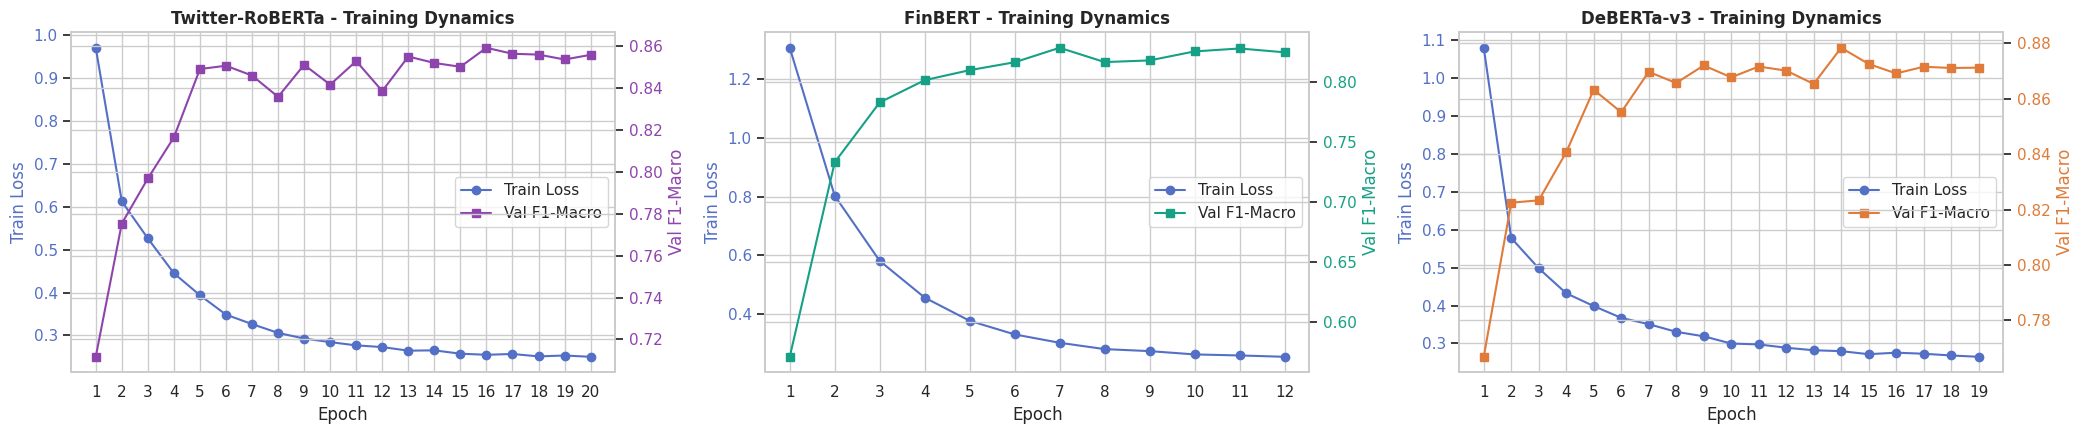

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 4.5))

for ax, (history, name, color) in zip(
    axes,
    [(twitter_history, 'Twitter-RoBERTa', '#8e44ad'),
     (finbert_history, 'FinBERT',         '#16a085'),
     (deberta_history, 'DeBERTa-v3',      '#e07b39')]
):
    epochs = range(1, len(history['val_f1']) + 1)
    ax2 = ax.twinx()
    l1, = ax.plot(epochs, history['train_loss'], 'o-', color='#5470c6', label='Train Loss')
    l2, = ax2.plot(epochs, history['val_f1'],    's-', color=color,    label='Val F1-Macro')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss', color='#5470c6')
    ax2.set_ylabel('Val F1-Macro', color=color)
    ax.set_title(f'{name} - Training Dynamics', fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelcolor='#5470c6')
    ax2.tick_params(axis='y', labelcolor=color)
    ax.set_xticks(list(epochs))
    ax.legend(handles=[l1, l2], loc='center right')

plt.tight_layout()
plt.show()

### 5.2 Results Table

Compare fine-tuned models with their frozen-embedding counterparts from notebook 06 and the strongest traditional ML baseline from notebook 04.

In [13]:
# Collect per-class metrics for both fine-tuned models
def build_row(model_name, y_true, y_pred):
    rep = classification_report(y_true, y_pred,
                                 target_names=['Bearish','Bullish','Neutral'],
                                 output_dict=True, zero_division=0)
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'F1-Macro' : round(f1_score(y_true, y_pred, average='macro'), 4),
        'P-Bearish': round(rep['Bearish']['precision'], 3),
        'R-Bearish': round(rep['Bearish']['recall'], 3),
        'P-Bullish': round(rep['Bullish']['precision'], 3),
        'R-Bullish': round(rep['Bullish']['recall'], 3),
        'P-Neutral': round(rep['Neutral']['precision'], 3),
        'R-Neutral': round(rep['Neutral']['recall'], 3),
    }

results = [
    build_row('Twitter-RoBERTa (fine-tuned)', y_val, twitter_preds),
    build_row('FinBERT (fine-tuned)',         y_val, finbert_preds),
    build_row('DeBERTa-v3 (fine-tuned)',      y_val, deberta_preds),
]

results_df = pd.DataFrame(results).sort_values('F1-Macro', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
print(results_df.to_string(index=False))

                       Model  Accuracy  F1-Macro  P-Bearish  R-Bearish  P-Bullish  R-Bullish  P-Neutral  R-Neutral
     DeBERTa-v3 (fine-tuned)    0.9026    0.8784      0.819      0.865      0.865      0.865      0.935      0.923
Twitter-RoBERTa (fine-tuned)    0.8889    0.8593      0.793      0.837      0.846      0.839      0.926      0.917
        FinBERT (fine-tuned)    0.8706    0.8282      0.760      0.771      0.803      0.803      0.918      0.915


### 5.3 Comparison vs Previous Notebooks

In [ ]:
# Baselines from previous notebooks - loaded dynamically instead of hardcoded.
ml_results_path = '../results/traditional_ml/ml_results.csv'
if os.path.exists(ml_results_path):
    ml_results  = pd.read_csv(ml_results_path)
    dl_keywords = ['RNN', 'BiRNN', 'LSTM']
    best_ml = ml_results.loc[
        ~ml_results['Model'].apply(lambda m: any(k in m for k in dl_keywords))
    ].sort_values('F1-Macro', ascending=False).iloc[0]
    TRADITIONAL_BEST_F1 = best_ml['F1-Macro']
else:
    # Fallback: SVM - LinearSVC (C=0.1) + BoW Binary (stem), captured from notebook 04
    # (../results/traditional_ml/ml_results.csv not generated yet)
    TRADITIONAL_BEST_F1 = 0.7603

embedding_results = pd.read_csv('../results/embeddings/transformer_embedding_results.csv')
best_frozen = embedding_results.sort_values('F1-Macro', ascending=False).iloc[0]
FROZEN_BEST_F1 = best_frozen['F1-Macro']

BASELINES = {
    'Best Traditional ML\n(LinearSVC + BoW Binary stem)' : TRADITIONAL_BEST_F1,
    f'Best Frozen Transformer\n({best_frozen["Model"]}, {best_frozen["Encoder"]}, nb 06)' : FROZEN_BEST_F1,
}

# Add fine-tuned scores
comparison = {
    **BASELINES,
    'Fine-tuned FinBERT'         : finbert_best_f1,
    'Fine-tuned DeBERTa-v3'      : deberta_best_f1,
    'Fine-tuned Twitter-RoBERTa' : twitter_best_f1,
}

# Sort
comparison_sorted = dict(sorted(comparison.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(11, 5))
labels = list(comparison_sorted.keys())
values = list(comparison_sorted.values())
colors = []
for k in labels:
    if 'Traditional' in k:        colors.append('#5b8db8')
    elif 'Frozen' in k:           colors.append('#94a3b8')
    elif 'FinBERT' in k:          colors.append('#16a085')
    elif 'DeBERTa' in k:          colors.append('#e07b39')
    else:                          colors.append('#8e44ad')

bars = ax.barh(labels, values, color=colors, edgecolor='white')

for bar, val in zip(bars, values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(min(values) - 0.02, max(values) + 0.04)
ax.set_xlabel('F1-Macro (Validation)')
ax.set_title('Fine-Tuning Gain over Frozen Embeddings and Traditional ML',
             fontsize=13, fontweight='bold')

# Reference lines
ax.axvline(TRADITIONAL_BEST_F1, color='#5b8db8', linestyle='--', alpha=0.5)
ax.axvline(FROZEN_BEST_F1, color='#94a3b8', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print deltas
print(f'\nFine-tuned Twitter-RoBERTa: F1 = {twitter_best_f1:.4f}')
print(f'  vs Best Traditional ML  (nb 04): {twitter_best_f1 - TRADITIONAL_BEST_F1:+.4f}')
print(f'  vs Best Frozen          (nb 06): {twitter_best_f1 - FROZEN_BEST_F1:+.4f}')

print(f'\nFine-tuned FinBERT: F1 = {finbert_best_f1:.4f}')
print(f'  vs Best Traditional ML  (nb 04): {finbert_best_f1 - TRADITIONAL_BEST_F1:+.4f}')
print(f'  vs Best Frozen          (nb 06): {finbert_best_f1 - FROZEN_BEST_F1:+.4f}')

print(f'\nFine-tuned DeBERTa-v3: F1 = {deberta_best_f1:.4f}')
print(f'  vs Best Traditional ML  (nb 04): {deberta_best_f1 - TRADITIONAL_BEST_F1:+.4f}')
print(f'  vs Best Frozen          (nb 06): {deberta_best_f1 - FROZEN_BEST_F1:+.4f}')

### 5.4 Per-Class Recall

Compare how each fine-tuned model handles the three classes. Fine-tuning typically improves the minority classes (Bearish/Bullish) more than Neutral, because gradient updates concentrate on the harder examples.

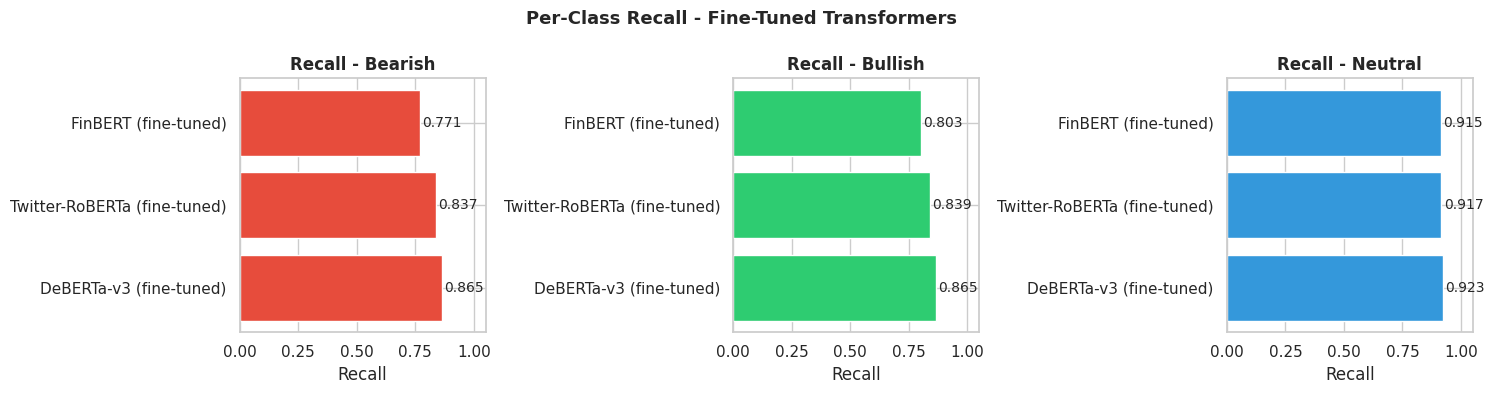

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cls, color in zip(axes,
                          ['Bearish', 'Bullish', 'Neutral'],
                          ['#e74c3c', '#2ecc71', '#3498db']):
    col = f'R-{cls}'
    sub = results_df.sort_values(col, ascending=False)
    bars = ax.barh(sub['Model'], sub[col], color=color, edgecolor='white')
    for bar, val in zip(bars, sub[col]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlim(0, 1.05)
    ax.set_title(f'Recall - {cls}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall')

plt.suptitle('Per-Class Recall - Fine-Tuned Transformers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.5 Confusion Matrices

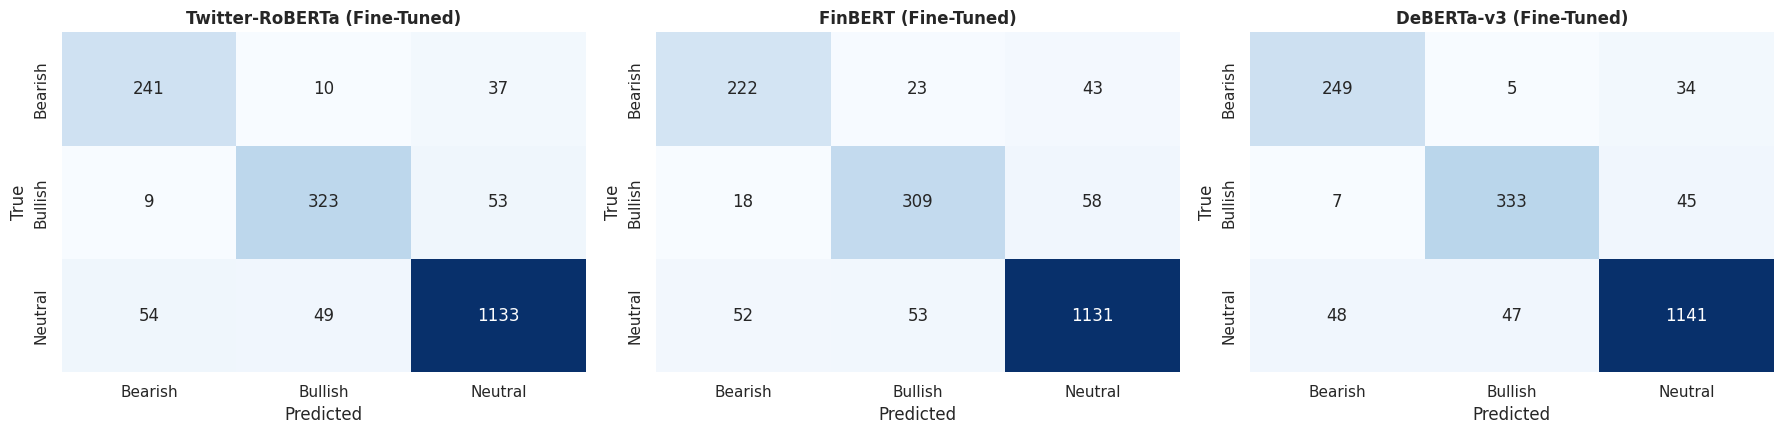

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, (preds, name) in zip(axes,
                              [(twitter_preds, 'Twitter-RoBERTa'),
                               (finbert_preds, 'FinBERT'),
                               (deberta_preds, 'DeBERTa-v3')]):
    cm = confusion_matrix(y_val, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'],
                ax=ax, cbar=False)
    ax.set_title(f'{name} (Fine-Tuned)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

<div id="6-predict" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">6. Test Set Predictions</h2>
</div>

Generate predictions on the test set with the best of the two fine-tuned models. Both prediction files are saved so the final notebook can pick the strongest submission.

In [17]:
def predict_test(model, tokenizer, model_label):
    test_ds = TweetDataset(x_test, labels=None, tokenizer=tokenizer, max_length=cfg.MAX_LENGTH)
    test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Predicting test ({model_label})'):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)

# Twitter-RoBERTa test predictions
twitter_test_preds = predict_test(twitter_model, twitter_tokenizer, 'Twitter-RoBERTa')

# FinBERT test predictions
finbert_test_preds = predict_test(finbert_model, finbert_tokenizer, 'FinBERT')

# DeBERTa-v3 test predictions
deberta_test_preds = predict_test(deberta_model, deberta_tokenizer, 'DeBERTa-v3')

# Distribution sanity check
print('\nTest prediction distribution:')
print('  Twitter-RoBERTa:', pd.Series(twitter_test_preds).map(LABEL_NAMES).value_counts().to_dict())
print('  FinBERT       :', pd.Series(finbert_test_preds).map(LABEL_NAMES).value_counts().to_dict())
print('  DeBERTa-v3    :', pd.Series(deberta_test_preds).map(LABEL_NAMES).value_counts().to_dict())

Predicting test (Twitter-RoBERTa):   0%|          | 0/150 [00:00<?, ?it/s]

Predicting test (FinBERT):   0%|          | 0/150 [00:00<?, ?it/s]

Predicting test (DeBERTa-v3):   0%|          | 0/150 [00:00<?, ?it/s]


Test prediction distribution:
  Twitter-RoBERTa: {'Neutral': 1541, 'Bullish': 484, 'Bearish': 363}
  FinBERT       : {'Neutral': 1559, 'Bullish': 479, 'Bearish': 350}
  DeBERTa-v3    : {'Neutral': 1531, 'Bullish': 491, 'Bearish': 366}


<div id="7-save" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#94a3b8;">7. Save Results</h2>
</div>

In [18]:
os.makedirs('../results', exist_ok=True)
os.makedirs('../results/models/finetuning', exist_ok=True)
os.makedirs('../results/finetuning', exist_ok=True)

# Validation results
results_df.to_csv('../results/finetuning/finetuning_results.csv', index=False)
results_df.to_pickle('../results/finetuning/finetuning_results.pkl')
print(f'Saved validation results -> ../results/finetuning/finetuning_results.csv')

# Training histories
with open('../results/finetuning/finetuning_histories.pkl', 'wb') as f:
    pickle.dump({
        'twitter_roberta': twitter_history,
        'finbert'        : finbert_history,
        'deberta_v3'     : deberta_history,
    }, f)
print(f'Saved training histories -> ../results/finetuning/finetuning_histories.pkl')

# Test predictions (one file per model; the better-scoring one becomes pred_XX.csv later)
twitter_subm = pd.DataFrame({'id': test_ids, 'label': twitter_test_preds})
finbert_subm = pd.DataFrame({'id': test_ids, 'label': finbert_test_preds})
deberta_subm = pd.DataFrame({'id': test_ids, 'label': deberta_test_preds})
twitter_subm.to_csv('../results/finetuning/test_predictions_twitter_roberta.csv', index=False)
finbert_subm.to_csv('../results/finetuning/test_predictions_finbert.csv',         index=False)
deberta_subm.to_csv('../results/finetuning/test_predictions_deberta.csv',         index=False)
print(f'Saved test predictions -> ../results/finetuning/test_predictions_*.csv')

# Save best model weights for re-use in the final pipeline notebook
torch.save(twitter_model.state_dict(),
           '../results/models/finetuning/twitter_roberta_best.pt')
torch.save(finbert_model.state_dict(),
           '../results/models/finetuning/finbert_best.pt')
torch.save(deberta_model.state_dict(),
           '../results/models/finetuning/deberta_best.pt')
print(f'Saved model weights -> ../results/models/finetuning/')

Saved validation results -> ../results/finetuning/finetuning_results.csv
Saved training histories -> ../results/finetuning/finetuning_histories.pkl
Saved test predictions -> ../results/finetuning/test_predictions_*.csv
Saved model weights -> ../results/models/finetuning/
